In [1]:
from pathlib import Path
import pandas as pd 
import numpy as np
from tqdm.autonotebook import tqdm as notebook_tqdm
notebook_tqdm.pandas()
import xgboost as xgb
from scipy.optimize import minimize_scalar
from sklearn.metrics import f1_score

root = Path('/data/data/malpolon/xgb') 

xgb.set_config(verbosity=0)

/tmp/ipykernel_9205/4148222209.py:4: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm as notebook_tqdm


In [33]:
## Load targets and Deep-SDM predictions
fulldf = pd.read_csv(root / 'database_split.csv', index_col='survey_id',
                     dtype = {22:str, 24:str, 25:str})

deepsdm_f1 = pd.read_csv(root / f'all-test-f1.csv', index_col = 0)
xgb_f1 = pd.read_csv(root / f'xgb-test-f1.csv', index_col = 0)
mm_f1 = pd.read_csv(root / f'all-test-f1-mm.csv', index_col = 0)


## Prepare data

In [5]:
def get_center_values(row):

    survey_id = row.name
    
    inputs_path = Path('/marbec-data/RLS-Australia/malpolon/inputs/australia/')

    filename = Path(inputs_path) / "env" / (str(survey_id) + '.npy')
    x = np.load(filename).astype(np.float32)
    env = np.transpose(x, (2, 0, 1))

    filename = Path(inputs_path) / "hum" / (str(survey_id) + '.npy')
    x = np.load(filename).astype(np.float32)
    hum = np.transpose(x, (2, 0, 1))

    envhum = np.concatenate([env, hum], axis=0)

    center_values = 0.25 * (envhum[:, 16, 16] + envhum[:, 15, 16] + envhum[:, 16, 15] + envhum[:, 15, 15])

    return center_values


In [6]:
X = fulldf[['subset']].progress_apply(get_center_values, axis=1, result_type='expand')
X.to_csv(root / f'X_center_values.csv')

100%|██████████| 27437/27437 [1:02:27<00:00,  7.32it/s]


## Train

In [3]:
# Prepare datasets

def get_datasets(sp):

    #X
    X = pd.read_csv(root / f'X_center_values.csv', index_col = 0)
    X_train = X.loc[fulldf['subset'] == 'train']
    X_val = X.loc[fulldf['subset'] == 'val']
    X_test = X.loc[fulldf['subset'] == 'test']

    # Y
    targets = (fulldf[sp] > 0).astype(float)
    Y_train = targets.loc[fulldf['subset'] == 'train'].astype('category')
    Y_val = targets.loc[fulldf['subset'] == 'val'].astype('category')
    Y_test = targets.loc[fulldf['subset'] == 'test'].astype('category')

    dtrain_clf = xgb.DMatrix(X_train, Y_train, enable_categorical=True)
    dval_clf = xgb.DMatrix(X_val, Y_val, enable_categorical=True)
    dtest_clf = xgb.DMatrix(X_test, Y_test, enable_categorical=True)

    return dtrain_clf, dval_clf, dtest_clf


In [ ]:
for sp in notebook_tqdm(deepsdm_f1.index.to_list()):

   # Train

   dtrain_clf, dval_clf, dtest_clf = get_datasets(sp)
   evals = [(dtrain_clf, "train"), (dval_clf, "validation")]

   params = {"objective": "binary:logistic", "tree_method": "hist", "device": "cuda","subsample":0.3,"max_depth":5,"eval_metric":"auc","base_score":0.5}
   n=500

   model = xgb.train(
      params=params,
      dtrain=dtrain_clf,
      num_boost_round=n,
      evals=evals,
      verbose_eval=10
   )

   # Export predictions

   targets = (fulldf[sp] > 0).astype(float)
   Y_train = targets.loc[fulldf['subset'] == 'train'].astype('category')
   Y_val = targets.loc[fulldf['subset'] == 'val'].astype('category')
   Y_test = targets.loc[fulldf['subset'] == 'test'].astype('category')

   print(sp)
   pd.Series(model.predict(dval_clf), name=sp, index = Y_val.index).to_csv(root / 'xgb-preds' / f"val_{sp.replace('/','-')}.csv")
   pd.Series(model.predict(dtest_clf), name=sp, index = Y_test.index).to_csv(root / 'xgb-preds' / f"test_{sp.replace('/','-')}.csv")

## Export predictions

In [ ]:
targets = (fulldf[sp] > 0).astype(float)
Y_train = targets.loc[fulldf['subset'] == 'train'].astype('category')
Y_val = targets.loc[fulldf['subset'] == 'val'].astype('category')
Y_test = targets.loc[fulldf['subset'] == 'test'].astype('category')

In [8]:
val_predictions = pd.Series(model.predict(dval_clf), name=sp, index = Y_val.index)
test_predictions = pd.Series(model.predict(dtest_clf), name=sp, index = Y_test.index)

In [9]:
val_predictions.to_csv(root / 'xgb-preds' / f'val_{sp}.csv')
test_predictions.to_csv(root / 'xgb-preds' / f'test_{sp}.csv')

## Calculate threshold

In [3]:
dfdict = {}

for sp in notebook_tqdm(deepsdm_f1.index.to_list()):

    dfdict[sp] = pd.read_csv(root / 'xgb-preds' / f"val_{sp.replace('/','-')}.csv", index_col=0).squeeze()

xgb_val = pd.DataFrame(dfdict)


100%|██████████| 1796/1796 [00:05<00:00, 316.07it/s]


In [4]:
# Find best threshold for species richness

def rvalue(thres, df, target_sr):
    sr = (df > thres).astype(int).sum(axis=1)
    
    return np.abs(sr.mean() - target_sr.mean())

    # a = linregress(target_sr, sr)
    # return -a.rvalue


targets_sr = (fulldf.loc[xgb_val.index, xgb_val.columns] > 0).sum(axis=1)
threshold = minimize_scalar(rvalue, args=(xgb_val, targets_sr),method='Bounded', bounds=(0,1))['x']
print(threshold)

0.07648724770728167


## Calculate F1

In [3]:
THRESHOLD = 0.076

dfdict = {}

for sp in notebook_tqdm(deepsdm_f1.index.to_list()):

    dfdict[sp] = pd.read_csv(root / 'xgb-preds' / f"test_{sp.replace('/','-')}.csv", index_col=0).squeeze()

xgb_test = (pd.DataFrame(dfdict) > THRESHOLD)

100%|██████████| 1796/1796 [00:04<00:00, 421.96it/s]


In [4]:
# Calculate average precision
scorename = 'f1' # / AP

dic = {}
for s in xgb_test.columns:
    preds = (xgb_test[s] > THRESHOLD).astype(float).to_numpy().flatten()
    targ = (fulldf.loc[xgb_test.index, s] > 0).astype(float).to_numpy().flatten()
    f1 = f1_score(targ, preds)
    dic[s] = {'f1': f1}
scores = pd.DataFrame(dic).T      

/data/venvs/xgb/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/data/venvs/xgb/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/data/venvs/xgb/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/data/venvs/xgb/lib/pytho

In [5]:
xgb_f1 = scores.sort_values(by=scorename, ascending=False)
xgb_f1.to_csv(root / f'xgb-test-{scorename}.csv')

## Compare

In [34]:
scores = pd.concat([xgb_f1["f1"], mm_f1["f1"]], axis = 1)
scores.columns = ['XGBoost', 'Deep-SDM']

In [37]:
scores.dropna(inplace=True)

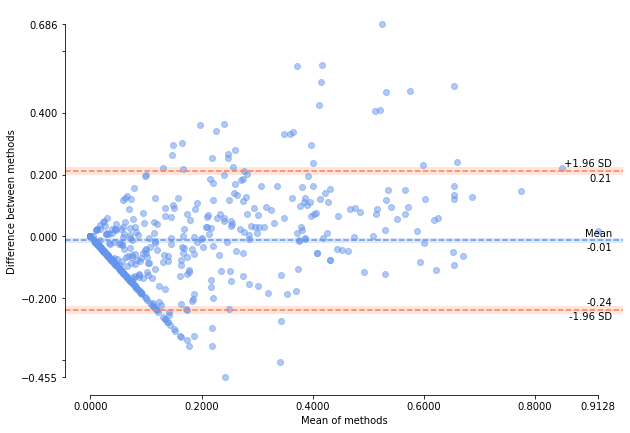

In [38]:
import pyCompare

pyCompare.blandAltman(scores['Deep-SDM'].values,scores['XGBoost'].values)

[Text(0.5, 0, 'XGB F1'), Text(0, 0.5, 'Deep F1')]

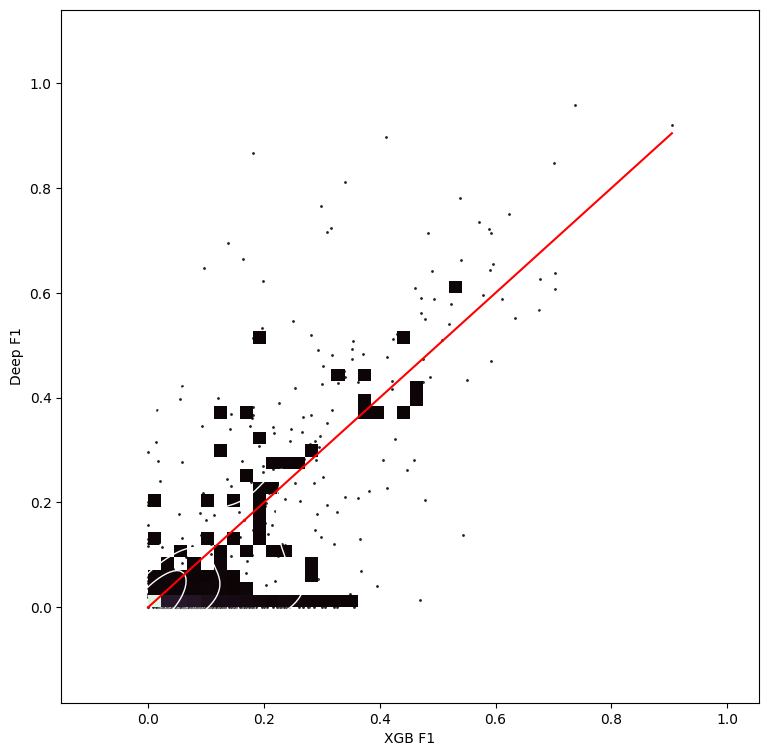

In [39]:
import seaborn as sns
from matplotlib import pyplot as plt

x, y = scores['XGBoost'].values, scores['Deep-SDM'].values

# Draw a combo histogram and scatterplot with density contours
f, ax = plt.subplots(figsize=(9, 9))
sns.scatterplot(x=x, y=y, s=5, color=".15")
sns.histplot(x=x, y=y, bins=40, pthresh=.1, cmap="mako")
sns.kdeplot(x=x, y=y, levels=5, color="w", linewidths=1)
sns.lineplot(x=[min(x), max(x)], y=[min(x), max(x)],color='red')
ax.set(xlabel='XGB F1', ylabel='Deep F1')

In [40]:
scores.sort_values(by='Deep-SDM', ascending=False)
scores.sort_values(by='XGBoost', ascending=False)

,XGBoost,Deep-SDM
Notolabrus tetricus,0.904464,0.921089
Notolabrus gymnogenis,0.737712,0.958131
Halichoeres melanurus,0.702532,0.637993
Pomacentrus moluccensis,0.701912,0.608000
Morwong fuscus,0.701528,0.848574
...,...,...
Acanthurus leucocheilus,0.000000,0.000000
Chrysiptera rex,0.000000,0.000000
Acanthurus spp.,0.000000,0.000000
Bovichtus angustifrons,0.000000,0.000000


In [41]:
y1 = scores[['XGBoost']].sort_values(ascending=False, by='XGBoost')
y1.reset_index(inplace=True)
y1.columns = ['species', 'F1']
y1['x'] = np.arange(len(y1))
y1['model'] = 'XGBoost'

y2 = scores[['Deep-SDM']].sort_values(ascending=False, by='Deep-SDM')
y2.reset_index(inplace=True)
y2.columns = ['species', 'F1']
y2['x'] = np.arange(len(y1))
y2['model'] = 'Deep-SDM'

data = pd.concat([y1, y2])
data

,species,F1,x,model
0,Notolabrus tetricus,0.904464,0,XGBoost
1,Notolabrus gymnogenis,0.737712,1,XGBoost
2,Halichoeres melanurus,0.702532,2,XGBoost
3,Pomacentrus moluccensis,0.701912,3,XGBoost
4,Morwong fuscus,0.701528,4,XGBoost
...,...,...,...,...
812,Amblyeleotris guttata,0.000000,812,Deep-SDM
813,Girella elevata,0.000000,813,Deep-SDM
814,Pomacentrus spp.,0.000000,814,Deep-SDM
815,Eubalichthys gunnii,0.000000,815,Deep-SDM


In [42]:
import plotly.express as px

fig = px.line(data[data['x'] <= 500], x='x', y='F1', color='model', template = 'simple_white',
           width = 800, height=600)

fig.update_layout(
    xaxis_title='Species rank',
    yaxis_title='F1 score')


In [43]:
scores['av'] = np.maximum(scores['XGBoost'], scores['Deep-SDM'])

<Axes: >

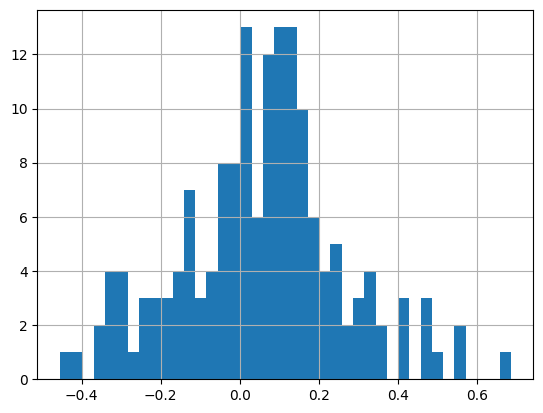

In [44]:
best_scores = scores[scores['av'] > 0.28]
(best_scores['Deep-SDM'] - best_scores['XGBoost']).hist(bins=40)

In [47]:
best_scores = scores.sort_values(by='XGBoost', ascending=False)
best_scores = best_scores[best_scores['av'] > 0.28]
best_scores['x'] = np.arange(len(best_scores))

In [48]:
import plotly.graph_objects as go
import numpy as np

# Example data
x = best_scores['x']
y1 = best_scores['XGBoost']
y2 = best_scores['Deep-SDM']
hover_text = best_scores.index.to_list()

# Create the figure
fig = go.Figure()

# Add the two series as scatter plots
fig.add_trace(go.Scatter(
    x=x, y=y1,
    mode='markers',
    marker=dict(color="#6FE0B9", size=10),
    name='XGBoost',
    hovertext=hover_text,
    hoverinfo='text'
))

fig.add_trace(go.Scatter(
    x=x, y=y2,
    mode='markers',
    marker=dict(color="#A296E7", size=10),
    name='Deep-SDM',
    hovertext=hover_text,
    hoverinfo='text'
))

# Add arrows for the differences
for i in range(len(x)):
    fig.add_annotation(
        ax=x[i], ay=y1[i],
        axref='x', ayref='y',
        x=x[i], y=y2[i],
        xref='x', yref='y',
        showarrow=True,
        arrowhead=1,
        arrowsize=1.5,
        arrowcolor="#E694EE",
        arrowwidth=1.5,
    )

# Update layout
fig.update_layout(
#     title='Chart with Arrows Showing Differences (Plotly)',
    width = 1200, height=800,
    template='simple_white'
)

# Show the figure
fig.show()

/tmp/ipykernel_9205/3325457192.py:35: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

/tmp/ipykernel_9205/3325457192.py:37: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

